# DSCI 303 - Homework 04

### Sean Graham

**Due: Sunday, June 1, 2020, 11:59 pm**

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## Part 1: Sample Mean and Variance

In [2]:
x = np.array([10, 16, 26, 12, 17, 22, 14, 12, 21, 16])
n = len(x)
mean = np.sum(x) / n
diff = x - mean
var = np.sum(diff ** 2) / (n-1)
print('Sample Mean:    ', mean)
print('Sample Variance:', var)

Sample Mean:     16.6
Sample Variance: 25.6


In [3]:
mean_np = np.mean(x)
var_np = np.var(x, ddof = 1)
print('Sample Mean:    ', mean_np)
print('Sample Variance:', var_np)

Sample Mean:     16.6
Sample Variance: 25.6


## Part 2: Scoring a Regression Model

In [4]:
def find_sse(true_y,pred_y):
    sse = np.sum((true_y - pred_y)**2)
    return sse

In [5]:
true_y = np.array([22.1, 17.9, 16.5, 14.3, 19.8, 23.7, 22.0, 18.4, 25.7, 19.2])
pred_1 = np.array([21.4, 16.7, 17.9, 12.1, 22.1, 25.1, 21.7, 19.3, 23.4, 19.9])
pred_2 = np.array([20.7, 18.1, 16.9, 13.6, 21.9, 24.8, 20.3, 21.1, 24.8, 18.4])

sse_1 = find_sse(true_y, pred_1)
sse_2 = find_sse(true_y, pred_2)

print('Model 1 SSE: ' + str(round(sse_1, 2)))
print('Model 2 SSE: ' + str(round(sse_2, 2)))

Model 1 SSE: 22.66
Model 2 SSE: 19.9


## Part 3: Scoring a Classification Model

In [6]:
def find_accuracy(true_y, pred_y):
    correct = np.sum(true_y == pred_y)
    accuracy = correct / len(true_y)
    return accuracy

In [7]:
true_diag = np.array(['P', 'P', 'N', 'N', 'P', 'N', 'N', 'N', 'P', 'N', 'N', 'N', 'N', 'P', 'P', 'N', 'N', 'N', 'N', 'N'])
pred_diag = np.array(['N', 'P', 'N', 'P', 'P', 'N', 'P', 'N', 'P', 'N', 'N', 'N', 'P', 'P', 'P', 'N', 'N', 'N', 'P', 'N'])

accuracy = find_accuracy(true_diag, pred_diag)
print('Model Accuracy: ' + str(accuracy))

Model Accuracy: 0.75


In [8]:
true_labels = np.array(['dog', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat'])
pred_labels = np.array(['dog', 'dog', 'cat', 'dog', 'cat', 'dog', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat'])

accuracy = find_accuracy(true_labels, pred_labels)
print('Model Accuracy: ' + str(accuracy))

Model Accuracy: 0.875


## Part 4: Classification Report

In [9]:
def classification_report(true_y, pred_y):
    classes = np.unique(true_y)
    negative_class = classes[0]
    positive_class = classes[1]
    
    accuracy = find_accuracy(true_y, pred_y)
    
    TP = np.sum((true_y == positive_class) & (pred_y == positive_class))
    FP = np.sum((true_y == negative_class) & (pred_y == positive_class))
    TN = np.sum((true_y == negative_class) & (pred_y == negative_class))
    FN = np.sum((true_y == positive_class) & (pred_y == negative_class))
    
    positive_precision = TP / (TP + FP)
    positive_recall = TP / (TP + FN)
    negative_precision = TN / (TN + FN)
    negative_recall = TN / (TN + FP)
    
    print('Positive Class:      ' + positive_class)
    print('Negative Class:      ' + negative_class)
    print()
    print('Accuracy:            ' + str(round(accuracy, 4)))
    print('Positive Precision:  ' + str(round(positive_precision, 4)))
    print('Positive Recall:     ' + str(round(positive_recall, 4)))
    print('Negative Precision:  ' + str(round(negative_precision, 4)))
    print('Negative Recall:     ' + str(round(negative_recall, 4)))

In [10]:
classification_report(true_diag, pred_diag)

Positive Class:      P
Negative Class:      N

Accuracy:            0.75
Positive Precision:  0.5556
Positive Recall:     0.8333
Negative Precision:  0.9091
Negative Recall:     0.7143


In [11]:
classification_report(true_labels, pred_labels)

Positive Class:      dog
Negative Class:      cat

Accuracy:            0.875
Positive Precision:  0.8333
Positive Recall:     0.9091
Negative Precision:  0.9167
Negative Recall:     0.8462


## Part 5: Transformation of Random Variables

In [12]:
np.random.seed(1)
X = np.random.normal(loc=0, scale=0.4, size=25000)
Y = np.exp(X)

mean_X = np.mean(X)
mean_Y = np.mean(Y)
std_X = np.std(X , ddof = 1)
std_Y = np.std(Y, ddof = 1)

print('Sample Mean of X:     ' + str(round(mean_X, 4)))
print('Sample Std Dev of X:  ' + str(round(std_X, 4)))
print('Sample Mean of Y:     ' + str(round(mean_Y, 4)))
print('Sample Std Dev of Y:  ' + str(round(std_Y, 4)))

Sample Mean of X:     0.0025
Sample Std Dev of X:  0.4002
Sample Mean of Y:     1.0862
Sample Std Dev of Y:  0.4537


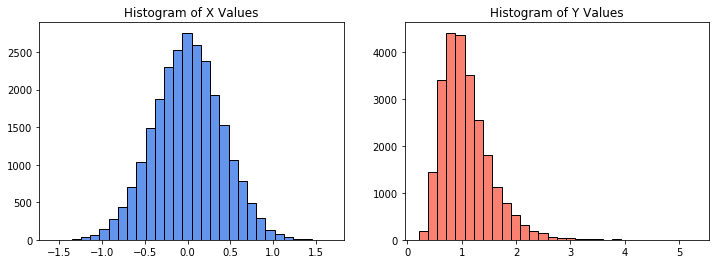

In [13]:
plt.figure(figsize = [12,4])
plt.subplot(1, 2, 1)
plt.hist(X, edgecolor = 'black', color = 'cornflowerblue', bins = 30)
plt.title('Histogram of X Values')

plt.subplot(1, 2, 2)
plt.hist(Y, edgecolor = 'black', color = 'salmon', bins = 30)
plt.title('Histogram of Y Values')

plt.show()

In [14]:
prob1 = np.mean(Y < 0.5)
prob2 = np.mean(Y < 1.0)
prob3 = np.mean(Y < 2.0)

print('Probability that Y is less than 0.5: ' + str(round(prob1, 4)))
print('Probability that Y is less than 1.0: ' + str(round(prob2, 4)))
print('Probability that Y is less than 2.0: ' + str(round(prob3, 4)))

Probability that Y is less than 0.5: 0.041
Probability that Y is less than 1.0: 0.4969
Probability that Y is less than 2.0: 0.9574


## Part 6: Stochastic Linear Relationships

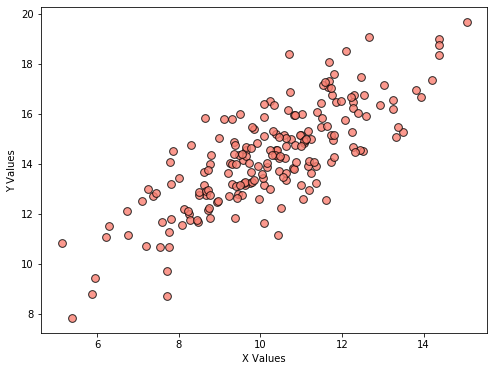

In [15]:
np.random.seed(1)
x_vals = np.random.normal(loc=10, scale=2, size=200)
errors = np.random.normal(loc=0, scale=1.2, size=200)
y_vals = 5.1 + 0.9 * x_vals + errors

plt.figure(figsize = [8,6])
plt.scatter(x = x_vals, y = y_vals, s = 60, alpha = 0.8, color = 'salmon', edgecolor = 'black')
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.show()

In [16]:
diff_x = x_vals - np.mean(x_vals)
diff_y = y_vals - np.mean(y_vals)
numerator = np.sum((diff_x * diff_y))
denominator = (np.sum(diff_x**2) * np.sum(diff_y**2))**.5
r = numerator / denominator

print('Correlation between X and Y: ' + str(round(r, 4)))

Correlation between X and Y: 0.7861


## Part 7: Relationship between Life Expectancy and Per Capita GDP

In [17]:
import pandas as pd
df = pd.read_csv('gapminder_data.txt', sep='\t') 
country = df.country.values
year = df.year.values
continent = df.continent.values
population = df.population.values
life_exp = df.life_exp.values
pcgdp = df.gdp_per_cap.values
gini = df.gini.values
df = None

In [18]:
continent_list = ['africa','americas','asia','europe']
color_list = ['salmon','palegreen','orchid','paleturquoise']

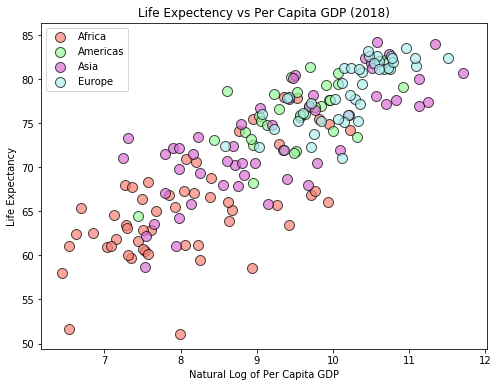

In [19]:
plt.figure(figsize = [8,6])
for i in range(0, len(continent_list)):
    sel = (continent == continent_list[i]) & (year == 2018)
    plt.scatter(x = np.log(pcgdp[sel]), y = life_exp[sel], s = 100, alpha = 0.7, color = color_list[i], edgecolor = 'black', label = continent_list[i].title())
    
plt.xlabel('Natural Log of Per Capita GDP')
plt.ylabel('Life Expectancy')
plt.title('Life Expectency vs Per Capita GDP (2018)')
plt.legend()
plt.show()

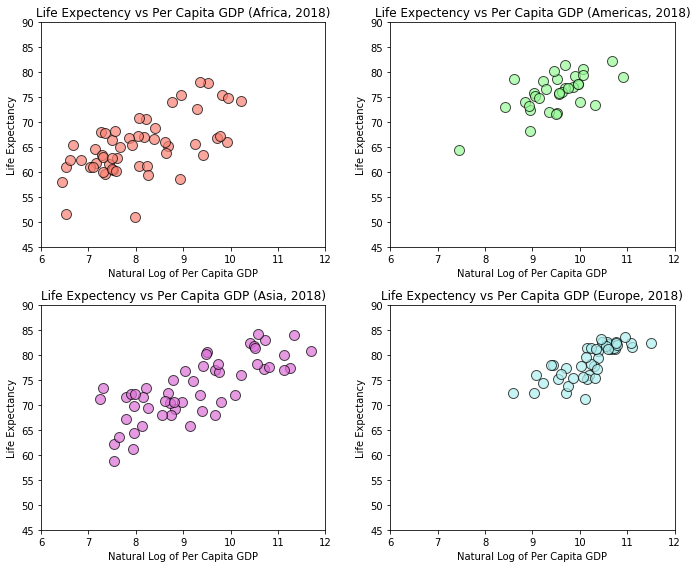

In [20]:
plt.figure(figsize = [10,8])
for i in range(0, len(continent_list)):
    sel = (continent == continent_list[i]) & (year == 2018)
    plt.subplot(2,2,i+1)
    plt.scatter(x = np.log(pcgdp[sel]), y = life_exp[sel], s = 100, alpha = 0.7, color = color_list[i], edgecolor = 'black', label = continent_list[i].title())

    plt.xlim([6,12])
    plt.ylim([45,90])
    plt.xlabel('Natural Log of Per Capita GDP')
    plt.ylabel('Life Expectancy')
    plt.title('Life Expectency vs Per Capita GDP (' + continent_list[i].title() + ', 2018)')
    
plt.tight_layout()
plt.show()

## Part 8: Trends by Country

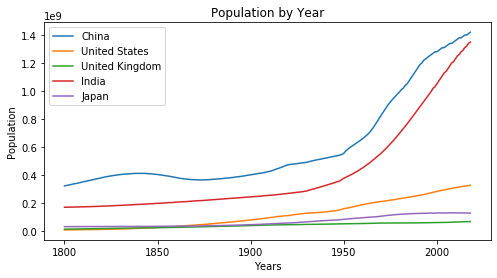

In [21]:
country_list = ['China','United States','United Kingdom','India','Japan']
year_range = list(range(1800,2019))

plt.figure(figsize = [8,4])
for i in range(0, len(country_list)): 
    sel = (country == country_list[i])
    country_data = list(population[sel])
    plt.plot(year_range, country_data)

plt.xlabel('Years')
plt.ylabel('Population')
plt.title('Population by Year')
plt.legend(country_list)
plt.show()

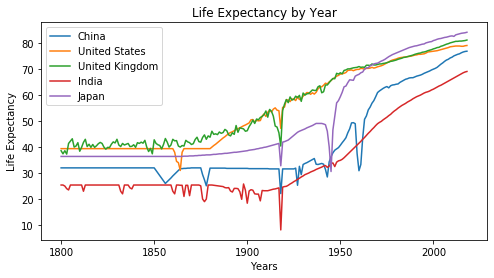

In [22]:
country_list = ['China','United States','United Kingdom','India','Japan']
year_range = list(range(1800,2019))

plt.figure(figsize = [8,4])
for i in range(0, len(country_list)): 
    sel = (country == country_list[i])
    country_data = list(life_exp[sel])
    plt.plot(year_range, country_data)

plt.xlabel('Years')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy by Year')
plt.legend(country_list)
plt.show()